In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data = pd.read_csv(r"D:\Dataset\Internship Fraud Detection\features_engineered.csv")


In [5]:
data

,amount,hour,day_of_week,is_new_device,is_fraud,card_present,amount_log,is_weekend,account_age_days,risk_score,...,location_fraud_count,location_total_count,location_fraud_rate,location_mismatch,risk_score_amount,segment_encoded,merchant_category_encoded,transaction_type_encoded,location_x_encoded,location_y_encoded
0,807.91,16,5,False,0,True,6.695688,1,1394,0.520467,...,348,38593,0.009017,0,420.490493,2,2,3,8,4
1,734.39,7,4,False,0,False,6.600401,0,256,0.592291,...,156,20274,0.007695,0,434.972340,2,3,2,7,3
2,2080.84,21,3,False,0,False,7.641007,0,968,0.512422,...,348,38593,0.009017,0,1066.267170,0,0,1,8,4
3,2521.49,21,3,False,0,True,7.833002,0,2621,0.451517,...,156,20274,0.007695,0,1138.495849,2,0,0,7,3
4,1802.67,10,4,False,0,False,7.497579,0,2281,0.452063,...,162,19497,0.008309,0,814.921024,2,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99101,1099.59,15,4,False,0,True,7.003602,0,3158,0.609415,...,100,9978,0.010022,0,670.106516,2,5,0,6,2
99102,3642.76,7,2,False,0,True,8.200771,0,2572,0.567092,...,156,20274,0.007695,0,2065.778705,0,3,1,7,3
99103,1668.13,16,2,False,0,True,7.420058,0,2625,0.548808,...,156,20274,0.007695,0,915.483352,3,3,1,7,3
99104,1370.69,6,2,False,0,True,7.223799,0,1454,0.391257,...,156,20274,0.007695,0,536.291989,0,4,0,7,3


In [6]:
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [10]:
smote

SMOTE(random_state=42)

In [11]:
model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [12]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [13]:
print("Logistic Regression Results:")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Results:
ROC-AUC Score: 0.9898

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     19610
           1       0.25      0.90      0.39       212

    accuracy                           0.97     19822
   macro avg       0.62      0.94      0.69     19822
weighted avg       0.99      0.97      0.98     19822



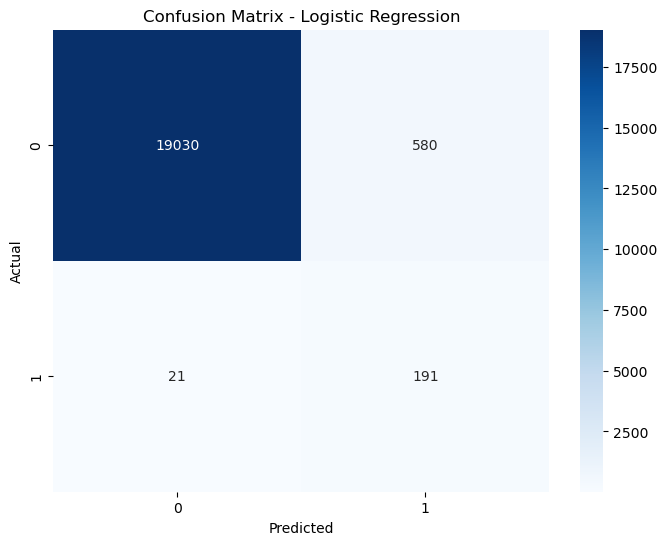

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

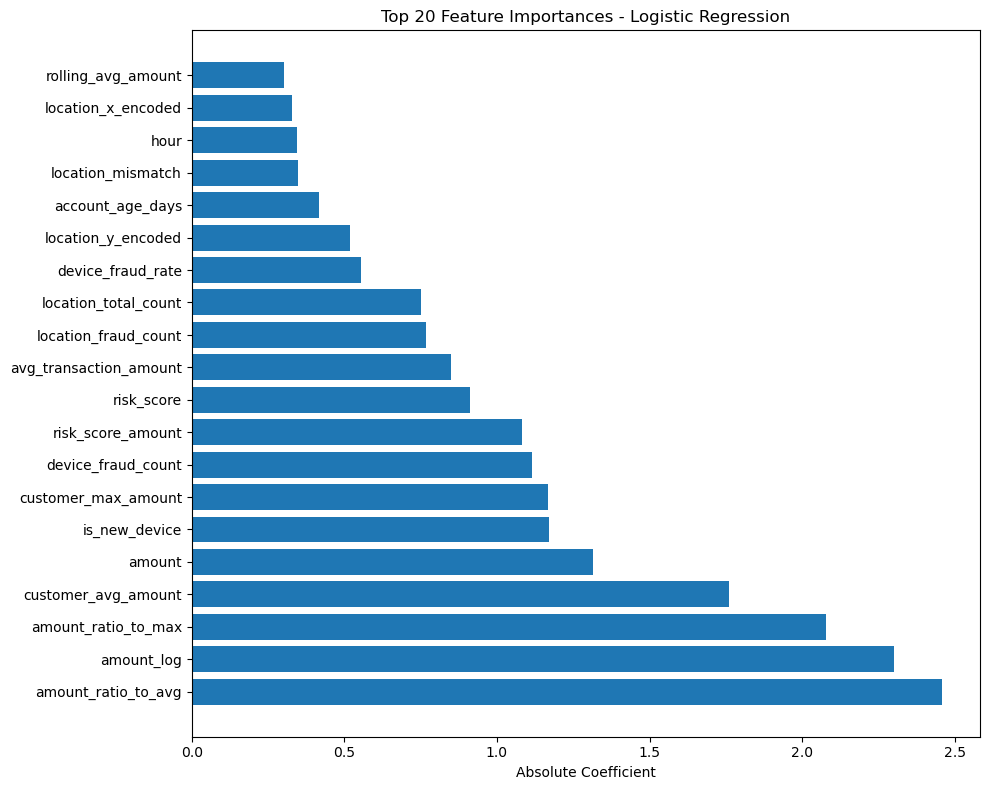

In [15]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(model.coef_[0])
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20])
plt.title('Top 20 Feature Importances - Logistic Regression')
plt.xlabel('Absolute Coefficient')
plt.tight_layout()
plt.show()

In [16]:
joblib.dump(model, 'D:\Dataset\Internship Fraud Detection\models\logistic_model.pkl')
joblib.dump(scaler, 'D:\Dataset\Internship Fraud Detection\models\scaler.pkl')
print("\nModel and scaler saved!")


Model and scaler saved!
